# 04 — Tucker-2 Decomposition  ⚡ FAST — this is what you run live

Phase 1 (sensitivity sweep) is the only part with any real cost, and it's
scoped down here (few validation batches, 5 candidate ratios per layer) to
finish in a couple of minutes on CPU or GPU — designed to be run live in
front of the audience. Phase 2 (budget distribution + compression) itself
is nearly instant.

If you want Phase 1 even faster for the demo, drop `MAX_BATCHES` further or
pre-compute `sensitivities`/`sweep_data` once and just re-run Phase 2 live
with different `GLOBAL_TARGET` values to show the trade-off interactively.

In [1]:
import sys, os, json, time
sys.path.append(os.path.abspath("../src"))
import torch
from torch.utils.data import DataLoader

from model import YOLOv3, count_conv_params
from loss import YOLOLoss
from dataset import CocoSubsetDataset, yolo_collate_fn
from tucker_decompose import (get_compressible_conv_layers, phase1_sensitivity_sweep,
                               phase2_compress, distribute_budget)

with open("../checkpoints/run_config.json") as f:
    cfg = json.load(f)
CLASS_NAMES, IMG_SIZE, DATA_ROOT, BATCH_SIZE = cfg["class_names"], cfg["img_size"], cfg["data_root"], cfg["batch_size"]
NUM_CLASSES = len(CLASS_NAMES)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


## Load the trained model

In [2]:
model = YOLOv3(num_classes=NUM_CLASSES)
state = torch.load("../checkpoints/yolov3_best.pt", map_location=DEVICE)
model.load_state_dict(state["model_state"])
model.to(DEVICE)

total_before, conv_before = count_conv_params(model)
print(f"loaded trained model: {total_before:,} total params ({conv_before:,} conv params)")

/tmp/ipykernel_3849/336072285.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load("../checkpoints/yolov3_best.pt", map_location=DEVICE)


loaded trained model: 61,545,274 total params (61,492,666 conv params)


## A small validation loader for the sensitivity sweep (doesn't need to be large)

In [3]:
val_ds = CocoSubsetDataset(DATA_ROOT, "val2017", CLASS_NAMES, img_size=IMG_SIZE,
                            images_per_class=30, augment=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=yolo_collate_fn, num_workers=0)
criterions = [YOLOLoss(NUM_CLASSES) for _ in range(3)]

layers = get_compressible_conv_layers(model)
print(f"{len(layers)} compressible conv layers (stem + prediction heads excluded)")

loading annotations into memory...
Done (t=0.47s)
creating index...
index created!
71 compressible conv layers (stem + prediction heads excluded)


## Phase 1 — per-layer sensitivity

Sweeps 5 compression ratios per layer, fits a degree-4 (biquadratic)
polynomial to (ratio, val-loss-delta), and takes `sensitivity = 2*|a2|`
— the curvature of that fit. Low sensitivity = the layer's loss barely
reacts to compression = safe to compress hard.

In [5]:
MAX_BATCHES = 4   # keep this small for a live demo; raise for a more accurate offline run
RATIOS = (0.9, 0.7, 0.5, 0.3, 0.1)

t0 = time.time()
sensitivities, sweep_data, baseline_loss = phase1_sensitivity_sweep(
    model, layers, val_loader, criterions, DEVICE, ratios=RATIOS, max_batches=MAX_BATCHES)
print(f"\nPhase 1 done in {time.time()-t0:.1f}s   baseline val loss: {baseline_loss:.4f}")

  [backbone.stage1.0.0] sensitivity=1612.57690  (loss_delta range 0.1465..17.0131)
  [backbone.stage1.1.conv1.0] sensitivity=405.85610  (loss_delta range 0.0517..11.7774)
  [backbone.stage1.1.conv2.0] sensitivity=526.24826  (loss_delta range 0.5917..9.3995)
  [backbone.stage2.0.0] sensitivity=341.55778  (loss_delta range -0.2680..7.0578)
  [backbone.stage2.1.conv1.0] sensitivity=210.91727  (loss_delta range -0.0396..4.6765)
  [backbone.stage2.1.conv2.0] sensitivity=108.67681  (loss_delta range 0.2992..5.7342)
  [backbone.stage2.2.conv1.0] sensitivity=346.27340  (loss_delta range 0.0098..3.4449)
  [backbone.stage2.2.conv2.0] sensitivity=177.42725  (loss_delta range 0.0531..2.9019)
  [backbone.stage3.0.0] sensitivity=171.79910  (loss_delta range 0.0746..4.0936)
  [backbone.stage3.1.conv1.0] sensitivity=213.57006  (loss_delta range 0.0655..5.6223)
  [backbone.stage3.1.conv2.0] sensitivity=239.98698  (loss_delta range -0.0406..3.5661)
  [backbone.stage3.2.conv1.0] sensitivity=2.43168  (los

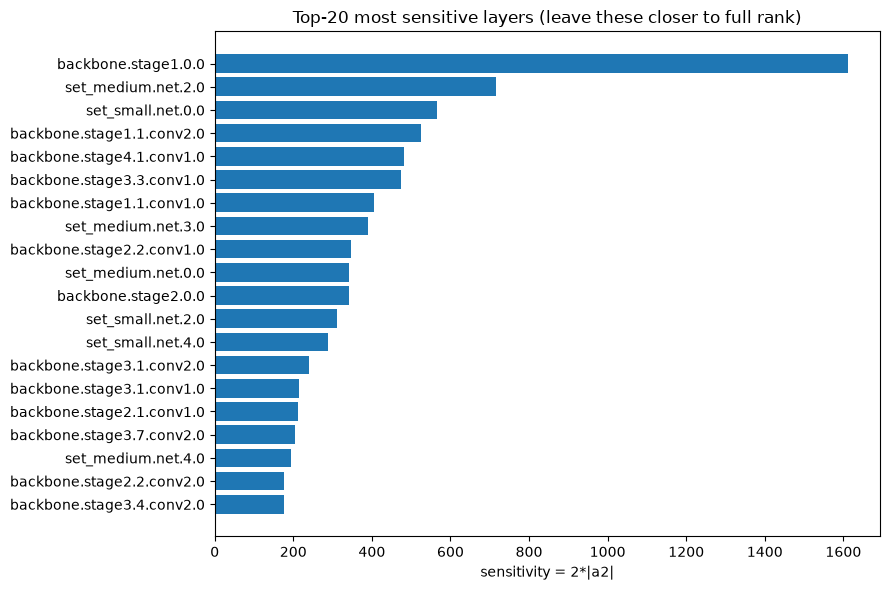

In [6]:
import matplotlib.pyplot as plt
names = list(sensitivities.keys())
vals = [sensitivities[n] for n in names]
order = sorted(range(len(names)), key=lambda i: -vals[i])[:20]

plt.figure(figsize=(9, 6))
plt.barh([names[i] for i in order][::-1], [vals[i] for i in order][::-1])
plt.xlabel("sensitivity = 2*|a2|")
plt.title("Top-20 most sensitive layers (leave these closer to full rank)")
plt.tight_layout()
plt.show()

In [7]:
import shutil
shutil.rmtree("../checkpoints/decomposition", ignore_errors=True)

## Phase 2 — inverse-sensitivity budget distribution + sequential compression

`GLOBAL_TARGET` is the overall fraction of compressible parameters you want
to keep (0.5 = compress compressible conv layers to ~50% of their original
size, before/after guardrails). This is the number to change live during
the demo to show different compression/accuracy trade-offs.

In [8]:
GLOBAL_TARGET = 0.5

per_layer_ratios = distribute_budget(sensitivities, GLOBAL_TARGET)
print("Per-layer target ratios (lower = compressed harder):")
for n, r in sorted(per_layer_ratios.items(), key=lambda kv: kv[1])[:10]:
    print(f"  {n:45s}  {r:.2f}")
print("  ...")

Per-layer target ratios (lower = compressed harder):
  backbone.stage5.4.conv2.0                      0.30
  backbone.stage5.3.conv2.0                      0.70
  set_large.net.1.0                              0.70
  backbone.stage5.3.conv1.0                      0.70
  backbone.stage5.2.conv2.0                      0.70
  backbone.stage5.1.conv2.0                      0.70
  backbone.stage4.8.conv1.0                      0.70
  backbone.stage3.7.conv1.0                      0.70
  backbone.stage3.2.conv1.0                      0.70
  backbone.stage5.2.conv1.0                      0.70
  ...


In [9]:
compressed_model, compression_log = phase2_compress(
    model, layers, sensitivities, sweep_data, GLOBAL_TARGET,
    ckpt_dir="../checkpoints/decomposition", device=DEVICE)

  compressed backbone.stage1.0.0: ratio=0.70  params 18,432 -> 12,232
  skipped backbone.stage1.1.conv1.0: factorization overhead exceeds savings (2,048 -> 4,488), kept original
  compressed backbone.stage1.1.conv2.0: ratio=0.70  params 18,432 -> 12,232
  compressed backbone.stage2.0.0: ratio=0.70  params 73,728 -> 49,452
  skipped backbone.stage2.1.conv1.0: factorization overhead exceeds savings (8,192 -> 18,124), kept original
  compressed backbone.stage2.1.conv2.0: ratio=0.70  params 73,728 -> 49,452
  skipped backbone.stage2.2.conv1.0: factorization overhead exceeds savings (8,192 -> 18,124), kept original
  compressed backbone.stage2.2.conv2.0: ratio=0.70  params 73,728 -> 49,452
  compressed backbone.stage3.0.0: ratio=0.70  params 294,912 -> 200,595
  skipped backbone.stage3.1.conv1.0: factorization overhead exceeds savings (32,768 -> 73,147), kept original
  compressed backbone.stage3.1.conv2.0: ratio=0.70  params 294,912 -> 200,595
  skipped backbone.stage3.2.conv1.0: factoriza

## Save the compressed model

In [10]:
from tucker_decompose import recalibrate_batchnorm

recal_ds = CocoSubsetDataset(DATA_ROOT, "train2017", CLASS_NAMES, img_size=IMG_SIZE,
                              images_per_class=30, augment=False)
recal_loader = DataLoader(recal_ds, batch_size=BATCH_SIZE, shuffle=True,
                           collate_fn=yolo_collate_fn, num_workers=0)

compressed_model = recalibrate_batchnorm(compressed_model, recal_loader, DEVICE, num_batches=20)
print("BatchNorm stats recalibrated")

loading annotations into memory...
Done (t=11.23s)
creating index...
index created!
BatchNorm stats recalibrated


In [11]:
torch.save(compressed_model.state_dict(), "../checkpoints/yolov3_compressed.pt")
with open("../checkpoints/compression_log.json", "w") as f:
    json.dump(compression_log, f, indent=2)

total_after, conv_after = count_conv_params(compressed_model)
print(f"conv params: {conv_before:,} -> {conv_after:,}  ({conv_after/conv_before:.1%} kept)")
print(f"total params: {total_before:,} -> {total_after:,}  ({total_after/total_before:.1%} kept)")
print("saved ../checkpoints/yolov3_compressed.pt")

conv params: 61,492,666 -> 26,355,577  (42.9% kept)
total params: 61,545,274 -> 26,408,185  (42.9% kept)
saved ../checkpoints/yolov3_compressed.pt


Forward-pass sanity check on the compressed model — shapes should be identical to the original.

In [12]:
x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
with torch.no_grad():
    outs = compressed_model(x)
print([tuple(o.shape) for o in outs])

[(1, 30, 13, 13), (1, 30, 26, 26), (1, 30, 52, 52)]
